In [66]:
import pandas as pd

In [67]:
df = pd.read_csv('placement.xls')

In [68]:
df.shape

(200, 2)

In [69]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


**Inspecting the relationship between CGPA and package with a scatter plot**

In [70]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'package')

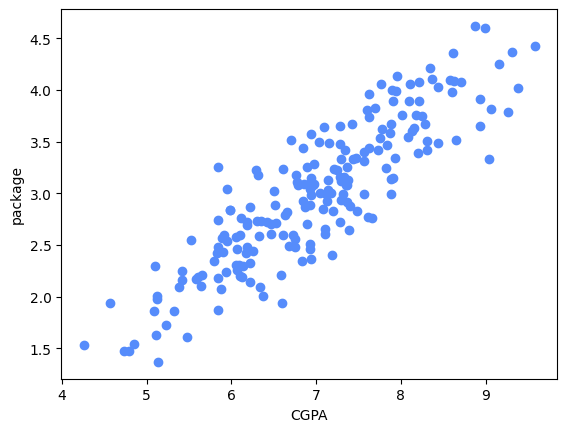

In [71]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('package')

**Splitting the dataset into training and testing sets**

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
x_train, x_test, y_train, y_test = train_test_split(df['cgpa'], df['package'], test_size=0.3, random_state=2)

## Model Training

**Training the linear regression model on the training data**

In [74]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train.values.reshape(-1, 1), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [75]:
model.coef_

array([0.55574241])

In [76]:
model.intercept_

np.float64(-0.8781178361812025)

In [77]:
y_pred = model.predict(x_test.values.reshape(-1, 1))

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Testing and Evaluation

**Plotting the regression line along with the test data points**

Text(0, 0.5, 'package')

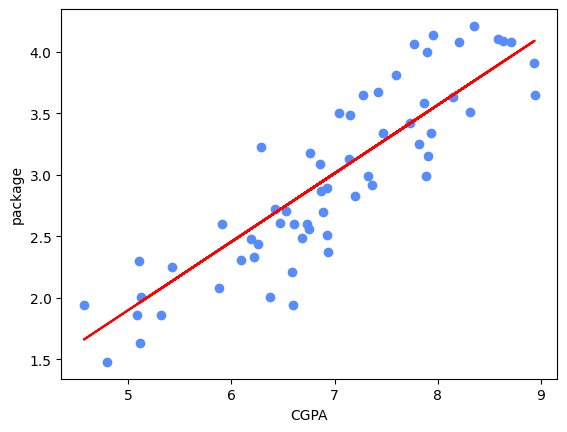

In [79]:
plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color='red')
plt.xlabel('CGPA')
plt.ylabel('package')

In [80]:
y_test, y_pred

(112    4.10
 29     3.49
 182    2.08
 199    2.33
 193    1.94
 85     1.48
 10     1.86
 54     3.09
 115    4.21
 35     2.87
 12     3.65
 92     4.00
 13     2.89
 126    2.60
 174    2.99
 2      3.25
 44     1.86
 3      3.67
 113    2.37
 14     3.42
 23     2.48
 25     3.65
 6      2.60
 134    2.83
 165    4.08
 173    2.56
 45     3.58
 65     3.81
 48     4.09
 122    2.01
 178    3.63
 64     2.92
 9      3.51
 57     1.94
 78     2.21
 71     3.34
 128    3.34
 176    3.23
 131    2.01
 53     2.61
 137    3.13
 163    3.91
 111    2.25
 123    2.30
 109    4.06
 141    3.18
 41     2.70
 130    2.49
 140    3.15
 5      2.99
 159    4.08
 100    4.14
 11     2.60
 187    2.44
 24     2.71
 89     2.72
 66     1.63
 8      2.31
 172    2.51
 175    3.50
 Name: package, dtype: float64,
 array([3.89015204, 3.09544039, 2.38964753, 2.57859995, 1.66162498,
        1.78388831, 2.07843178, 2.93427509, 3.76233128, 2.93983252,
        4.09021931, 3.5122472 , 2.97317706, 2.406319

**Evaluating the trained model using error metrics**

In [81]:
mean_squared_error(y_test, y_pred)

0.1185889515124916

In [82]:
mean_absolute_error(y_test, y_pred)

0.2874910067960929

In [83]:
r2_score(y_test, y_pred)

0.7736419609402847

**Checking the model prediction on a single test sample**


In [84]:
# Use positional indexing to get one test sample safely.
sample = [[x_test.iloc[0]]]
prediction = model.predict(sample)
actual = y_test.iloc[0]

In [85]:
print("Predicted package:", prediction[0])
print("Actual package:", actual)

Predicted package: 3.8901520386679294
Actual package: 4.1
